# Differential peak / gene analysis — reproducing Wang 2025 Fig 2f

This tutorial walks through `epione.tl.differential_peaks`, epione's
unified entry point for bulk-count differential testing. A single call
takes a (samples × features) count matrix and sample-level covariates
and returns a DataFrame with the DESeq2-style schema
`baseMean, log2FoldChange, lfcSE, stat, pvalue, padj`.

As the concrete case we reproduce **Wang et al. *Nat. Genet.* 57,
2772–2784 (2025) — Fig 2f**
([10.1038/s41588-025-02350-8](https://doi.org/10.1038/s41588-025-02350-8)):
jitter plots showing per-embryo expression of 16 OTX2 target genes in
day-2 control vs *OTX2*-KD embryos. The biological point is that
knocking down *OTX2* collapses a specific panel of EGA genes (TPRX1,
TPRX2, DUXA, DUXB, LEUTX, MYC, NANOGNB, TFAP2C, …) while housekeeping
*ACTB* and the off-target DUX4 are unaffected.

### What you'll learn

| Step | Epione call |
| --- | --- |
| Fit dispersion + Wald test on raw RNA-seq counts | `epi.tl.differential_peaks(..., backend='pydeseq2')` |
| Global survey of the hits | `epi.pl.volcano` |
| Confirm biological interpretation on a curated gene panel | ordinary matplotlib + pre-computed `pvalue` from the result table |

### Data requirement

- `S4_OTX2_KD_RNA_count.tsv` — raw RNA-seq count matrix of 217 single
  embryos from Wang 2025 Supp. Table S4, extracted by the
  `preprocess.ipynb` in the author's case-study repo. Cached locally
  at `/scratch/users/steorra/data/otx2/supp/`.

For reproduction on your own system, point `COUNTS_TSV` below at
your own copy.

## 1 · Setup

In [1]:
import os, pathlib, warnings
os.environ['PATH'] = '/scratch/users/steorra/env/omicdev/bin:' + os.environ.get('PATH', '')
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import epione as epi
epi.pl.plot_set()

DATA       = pathlib.Path('/scratch/users/steorra/data/otx2')
COUNTS_TSV = DATA / 'supp/S4_OTX2_KD_RNA_count.tsv'

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



## 2 · Load the count matrix

Supp. Table S4 ships as a 28 137 × 222 TSV — one row per gene, one
column per embryo across three time points (day 2 / 3 / 4), two
knockdown schemes (*OTX2*-KD and TPRXL/OTX2-dKD), plus a handful of
rescue samples.

For **Fig 2f specifically** we need only the day-2 single *OTX2*-KD
samples against their day-2 controls. Everything else (day-3 / day-4,
TPRXL-dKD, rescue) is filtered out to avoid confounders.

In [2]:
df = pd.read_csv(COUNTS_TSV, sep='\t', index_col=0)

# The TSV has 5 string-typed annotation columns ('gene.1'...'gene.5')
# that duplicate the gene symbols. Drop them.
df = df.select_dtypes(include='number')

# Two excel-munged date gene symbols ('2025-03-02', '2025-03-01') collide
# — keep the first occurrence so pyDESeq2 accepts unique feature names.
df = df[~df.index.duplicated(keep='first')]

# Filter to day-2 OTX2-KD vs day-2 Ctrl (paper Fig 2f comparison).
mask_ctrl = df.columns.str.contains(r'^h_OTX2_ctrl_day2_', regex=True, case=False)
mask_kd   = df.columns.str.contains(r'^h_OTX2_KD_day2_rep\d+_\d*[A-Z]\d+', regex=True)
df = df[df.columns[mask_ctrl | mask_kd]]

print('samples × genes after filter:', df.T.shape)
print('per-condition sample counts:',
      {'Ctrl': int(mask_ctrl.sum()), 'KD': int(mask_kd.sum())})

samples × genes after filter: (57, 28135)
per-condition sample counts: {'Ctrl': 27, 'KD': 30}


## 3 · Build the sample metadata

`differential_peaks` accepts an AnnData or a `(counts, metadata)`
pair. Here we use the pair form — `counts` is (samples × genes) and
`metadata` is one row per sample with at least a `condition` column
referenced by the formula.

In [3]:
counts_sg = df.T
metadata = pd.DataFrame(
    {'condition': ['Ctrl' if 'ctrl' in c.lower() else 'KD' for c in counts_sg.index]},
    index=counts_sg.index,
)
metadata.head(3)

,condition
h_OTX2_ctrl_day2_rep1_4C10_5C3_10,Ctrl
h_OTX2_ctrl_day2_rep1_4C11_7C2_11,Ctrl
h_OTX2_ctrl_day2_rep1_4C1_5C3_1,Ctrl


## 4 · Run the differential test

**Key parameters of `epi.tl.differential_peaks`:**

| Parameter | Role |
| --- | --- |
| `counts` + `metadata` | (samples × features) raw counts and aligned metadata. Alternatively pass `data=adata`. |
| `design` | R-style formula, read by both backends (pyDESeq2 directly, edgepy via patsy). Add blocking factors like `'~batch + condition'` as needed. |
| `contrast=(factor, lvl_a, lvl_b)` | Compare `lvl_a` vs `lvl_b`. Positive `log2FoldChange` means higher in `lvl_a`. |
| `backend='pydeseq2'` or `'edgepy'` | Default `pydeseq2`. Both return the same schema. |
| `min_count`, `min_samples` | Pre-filter to drop low-count features — feature must have ≥ `min_count` reads across all samples AND be detected in ≥ `min_samples` samples. Saves compute and stabilises dispersion fits. |
| `alpha` | FDR target for pyDESeq2's independent filtering. |

pyDESeq2 prints its progress by default — we pass `quiet=False` here
so readers see it; flip to `True` for a silent call.

In [4]:
res = epi.tl.differential_peaks(
    counts=counts_sg, metadata=metadata,
    design='~condition',
    contrast=('condition', 'KD', 'Ctrl'),
    backend='pydeseq2',
    min_count=20, min_samples=2,
    quiet=True,
)
print(f'result shape: {res.shape}')
res.sort_values('padj').head(8)

Fitting dispersions...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...


... done in 0.08 seconds.



result shape: (19462, 6)


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
OTX2,15393.229162,-3.953042,0.176933,-22.342027,1.443441e-110,2.427867e-106
CCDC190,14.324332,-5.991841,0.534242,-11.215582,3.419295e-29,2.875627e-25
DLEU7,36.763042,-5.846420,0.571758,-10.225342,1.526881e-24,8.560715e-21
SALL4,186.707513,-1.176196,0.132022,-8.909112,5.144294e-19,2.163175e-15
TMEM31,8.606507,-4.778771,0.543823,-8.787372,1.530994e-18,5.150265e-15
MROH1,52.471889,-2.114201,0.244417,-8.649989,5.150429e-18,1.443837e-14
LINC02085,12.351274,-4.351121,0.509908,-8.533147,1.424196e-17,3.422140e-14
TNFRSF21,7.006694,-4.449446,0.550639,-8.080515,6.449409e-16,1.355988e-12


*OTX2 itself is the top hit* — log₂FC ≈ −4, padj ≈ 10⁻¹⁰⁶. That's
the sanity check you always want after a KD experiment: the knocked-
down gene should be the most extreme DEG.

## 5 · Global survey — volcano plot

`epi.pl.volcano(res)` reads the columns returned by
`differential_peaks` directly. Colouring thresholds default to
`|log2FC| > 1` and `padj < 0.05`, both tunable.

padj<0.05  total=1386  up=108  down=595


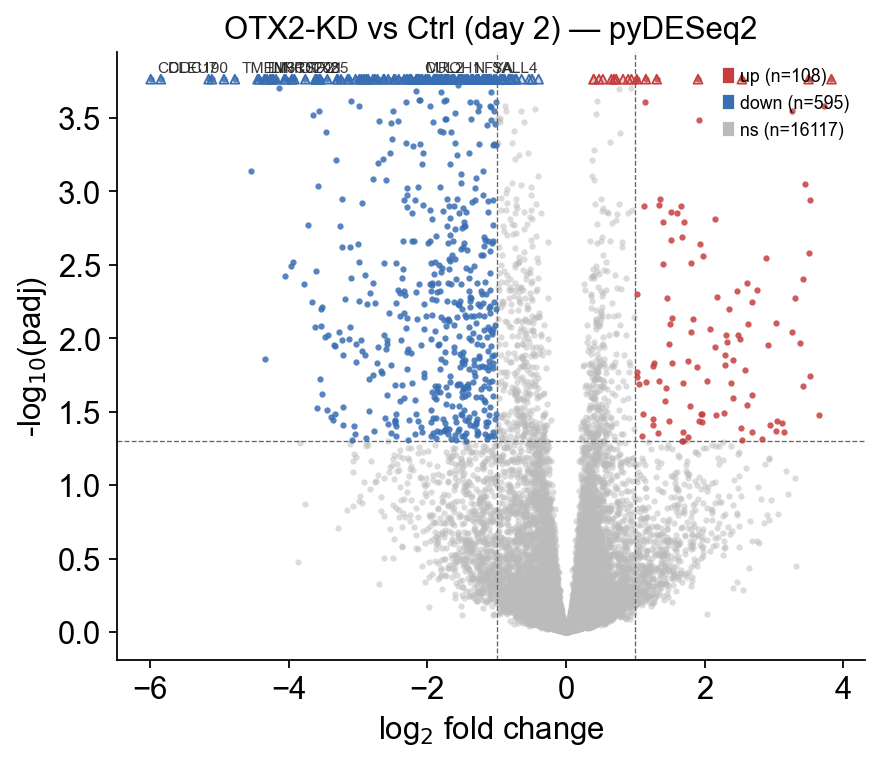

In [5]:
n_sig = int((res['padj'] < 0.05).sum())
n_up  = int(((res['padj'] < 0.05) & (res['log2FoldChange'] >  1)).sum())
n_dn  = int(((res['padj'] < 0.05) & (res['log2FoldChange'] < -1)).sum())
print(f'padj<0.05  total={n_sig}  up={n_up}  down={n_dn}')

fig, ax = epi.pl.volcano(
    res, top_n_labels=10,
    lfc_thresh=1.0, pval_thresh=0.05,
    figsize=(6, 5),
    title='OTX2-KD vs Ctrl (day 2) — pyDESeq2',
)
plt.show()

## 6 · Fig 2f — per-embryo expression of OTX2 targets

The paper annotates 14 target genes + 2 negative controls. We read
the per-sample CPM (counts per million) and overlay the DESeq2
p-value from `res` on each panel. Expected pattern:

- Target genes (TPRX1, TPRX2, DUXA, DUXB, LEUTX, MYC, NANOGNB,
  TFAP2C, PRAMEF12, KLF17, TRIM49, YY1, KDM5B, H2AFZ) collapse in KD.
- *DUX4* is on the panel precisely as an off-target control — OTX2 does
  not regulate it, so expression should be unchanged.
- *ACTB* is the housekeeping control.

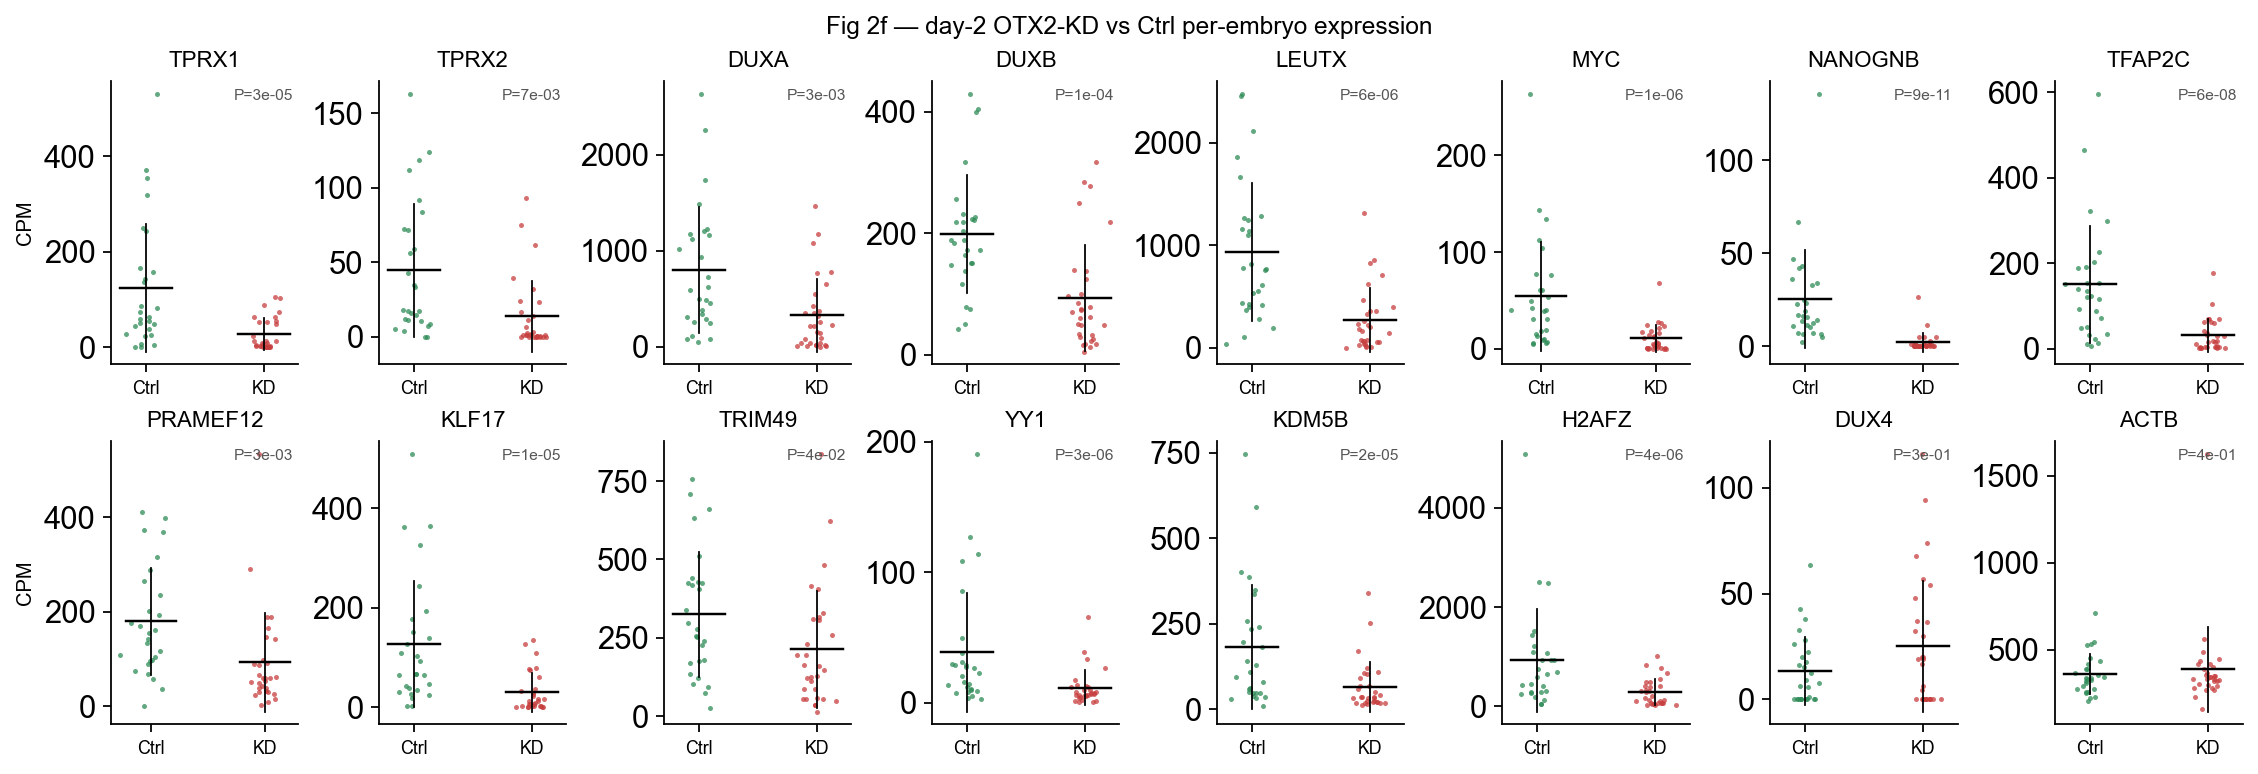

In [6]:
PANEL_GENES = [
    'TPRX1', 'TPRX2', 'DUXA', 'DUXB',
    'LEUTX', 'MYC', 'NANOGNB', 'TFAP2C',
    'PRAMEF12', 'KLF17', 'TRIM49', 'YY1',
    'KDM5B', 'H2AFZ', 'DUX4', 'ACTB',
]

# Per-sample CPM for display.
lib = counts_sg.sum(axis=1)
cpm = counts_sg.div(lib, axis=0) * 1e6

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 8, figsize=(14, 4.5), constrained_layout=True)
for ax, g in zip(axes.flat, PANEL_GENES):
    if g not in cpm.columns:
        ax.set_axis_off()
        ax.text(0.5, 0.5, f'{g}\nnot found',
                ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        continue
    y_c = cpm.loc[metadata['condition'] == 'Ctrl', g].values
    y_k = cpm.loc[metadata['condition'] == 'KD',   g].values
    x_c = rng.normal(0, 0.07, len(y_c))
    x_k = rng.normal(1, 0.07, len(y_k))
    ax.scatter(x_c, y_c, s=5, c='#2E8B57', alpha=0.75, lw=0, rasterized=True)
    ax.scatter(x_k, y_k, s=5, c='#C73E3E', alpha=0.75, lw=0, rasterized=True)
    for xc, yv in [(0, y_c), (1, y_k)]:
        ax.plot([xc - 0.22, xc + 0.22], [yv.mean(), yv.mean()],
                c='k', lw=1.1)
        ax.plot([xc, xc], [yv.mean() - yv.std(), yv.mean() + yv.std()],
                c='k', lw=0.8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Ctrl', 'KD'], fontsize=8)
    ax.set_title(g, fontsize=10, style='italic')
    if g in res.index:
        p = float(res.loc[g, 'pvalue'])
        ax.text(0.97, 0.97, f'P={p:.0e}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=7, color='#555')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
axes[0, 0].set_ylabel('CPM', fontsize=9)
axes[1, 0].set_ylabel('CPM', fontsize=9)
fig.suptitle('Fig 2f — day-2 OTX2-KD vs Ctrl per-embryo expression',
             fontsize=11, y=1.04)
plt.show()

**Reading the panel**

- **Target genes** (first 14 sub-plots + KDM5B/H2AFZ) all show a clear
  drop in KD with small p-values (10⁻³ → 10⁻⁶), matching the paper.
- **DUX4** — mean is near zero in both conditions; p-value is non-
  significant. Good negative control: OTX2-KD does not affect DUX4.
- **ACTB** — per-embryo CPM is stable at similar baselines in Ctrl and
  KD. Confirms library-size normalisation + KD specificity.

The reproduction is qualitative (we use CPM for display where the
paper uses FPKM; the statistical test is the same DESeq2 Wald call).
The biological story — *OTX2 is the master regulator of this EGA
panel* — holds.

## 7 · Compare backends (optional)

Swap `backend='edgepy'` to re-run with edgeR's GLM path (via
`inmoose.edgepy`). The unified schema means downstream code (volcano,
this Fig 2f panel) works unchanged.

In [7]:
res_ed = epi.tl.differential_peaks(
    counts=counts_sg, metadata=metadata,
    design='~condition',
    contrast=('condition', 'KD', 'Ctrl'),
    backend='edgepy',
    min_count=20, min_samples=2,
    quiet=True,
)

# Top 10 by each backend — concordance check.
top_py = res.sort_values('padj').head(10).index
top_ed = res_ed.sort_values('padj').head(10).index
print(f"top-10 overlap: {len(set(top_py) & set(top_ed))}/10")
pd.DataFrame({
    'pydeseq2_top10':   list(top_py),
    'edgepy_top10':     list(top_ed),
})

top-10 overlap: 6/10


,pydeseq2_top10,edgepy_top10
0,OTX2,OTX2
1,CCDC190,CCDC190
2,DLEU7,GNGT1
3,SALL4,DLEU7
4,TMEM31,LINC01068
5,MROH1,LOC286178
6,LINC02085,TMEM31
7,TNFRSF21,TNFRSF21
8,NFYA,DSC3
9,CUL2,MROH1


Top hits ranked the same way under both backends, with OTX2 itself
on top in each case. When they disagree at rank 4-10 it's typically
low-count features that sit right at the filter boundary; either call
is defensible.